# Scenario B1 Mixed: Multiple Suppliers — No REC (Mixed Prosumers)

**Description:** Two independent suppliers, no REC, with mixed prosumer profiles.
Prosumers are modelled as **full prosumers** — both local load AND RES generation
are billed, reflecting realistic household-with-PV behaviour.
Each balancing group contains a single member type (consumers only or prosumers only).

**Participant–supplier assignment:**
| Supplier / BG | Participants |
|---|---|
| SUP_A / BG_A | consumer_001–006 (6 consumers) |
| SUP_B / BG_B | prosumer_001–003 (3 prosumers) |

**Configuration:**
| Parameter | Value |
|---|---|
| Suppliers | 2 — SUP_A, SUP_B |
| Balancing Groups | 2 — BG_A (6 consumers), BG_B (3 prosumers) |
| RECs | None |
| Prosumer type | **Mixed** (RES + local load both billed) |
| Battery | None |

**Research role:** Multi-supplier baseline with homogeneous balancing groups.
BG_A is a pure-consumer group (no generation), while BG_B carries all PV
generation alongside prosumer loads. Compared to A1-mixed, reveals how
multi-supplier fragmentation with member-type separation reshapes each
supplier's balancing position and P&L.

**Comparison pairs (mixed-prosumer track):**
- B1-mixed vs A1-mixed → effect of multi-supplier competition (no REC)
- B1-mixed vs B2-mixed → incremental value of adding a cross-supplier REC
- B1-mixed vs B2-forecasts-mixed → REC value under explicit forecast scheduling

## 1. Import Dependencies
Import the EnergyMarketOperations class which handles the complete market simulation pipeline.

In [42]:
from energy_market_operations import EnergyMarketOperations

## 2. Initialize Pipeline
Load the scenario configuration from JSON and create the pipeline instance. The config specifies participants, suppliers, market prices, and network topology.

In [43]:
CONFIG_FILE = "B1_multiple_suppliers_without_rec(mixed prosumers).json"
pipe = EnergyMarketOperations(CONFIG_FILE, scenario_name="B1_mixed_prosumers")

## 3. Run Full Pipeline
Execute the complete market simulation:
1. **Day-Ahead Market** - Schedule energy positions based on DA forecasts (per BG)
2. **Intra-Day Market** - Adjust positions with updated ID forecasts (per BG)
3. **REC Settlement** - (Skipped for B1 - no REC configured)
4. **Balancing Market** - Settle imbalances at dual pricing (per BG)
5. **Supplier Billing** - Calculate final costs per participant

In [44]:
pipe.run_all()


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Running full pipeline for: B1_mixed_prosumers
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  SCENARIO: B1_mixed_prosumers
  System  : Multiple Suppliers without REC - Scenario B1
  Period  : 2016-01-01 → 2016-12-31
  Suppliers    : 2
  Prosumers    : 3
  Consumers    : 6
  RECs         : 0  →  has_rec = False
  Battery      : False
✓ Prices loaded: (35136, 5)  from prices.csv
✓ Load actual : (35136, 153)
✓ RES actual  : (35136, 27)
✓ Load forecast DA: (35136, 9)
✓ RES  forecast DA: (35136, 3)
✓ Load forecast ID: (35136, 9)
✓ RES  forecast ID: (35136, 3)
✓ DA market: (70272, 8)
✓ ID market : (70272, 19)
⚠ Battery optimization: skipped (no battery in config)
✓ REC settlement: SKIPPED (no RECs in config)
✓ Balancing market: (70272, 27)
✓ Customer billing: (316224, 12)  (9 customers)
✓ Monthly aggregation: (24, 26)
✓ Profit/loss calculated

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

## 4. Financial Summary
Display aggregated financial results including total revenues, costs, and profit/loss for each supplier.

In [34]:
pipe.summary()


  ANNUAL FINANCIAL SUMMARY – B1_MIXED_PROSUMERS

  SUP_A (Supplier A):

    REVENUES:
      Energy Market Sales : €        0.00
      Balancing Rewards   : €       18.51
      Retail Sales        : €   29,814.30
      ────────────────────────────────────────────
      Total Revenue       : €   29,832.81

    COSTS:
      Market Purchases    : €    4,749.35
      Balancing Penalties  : €       18.87
      Retail Purchases     : €        0.00
      ────────────────────────────────────────────
      Total Costs          : €    4,768.22

    PROFIT/LOSS:
      Annual Total         : €   25,064.59
      Monthly Average      : €    2,088.72

    IMBALANCE:
      System Position      : SHORT
      Total Imbalance      :         0.00 MWh
      BG Actual Position   :       148.33 MWh
      BG Forecast Position :       148.33 MWh

  SUP_B (Supplier B):

    REVENUES:
      Energy Market Sales : €      741.57
      Balancing Rewards   : €       64.23
      Retail Sales        : €    8,139.09
   

## 5. Financial Visualization
Plot breakdown of revenues and costs by category (DA purchases, ID adjustments, balancing costs, customer sales).

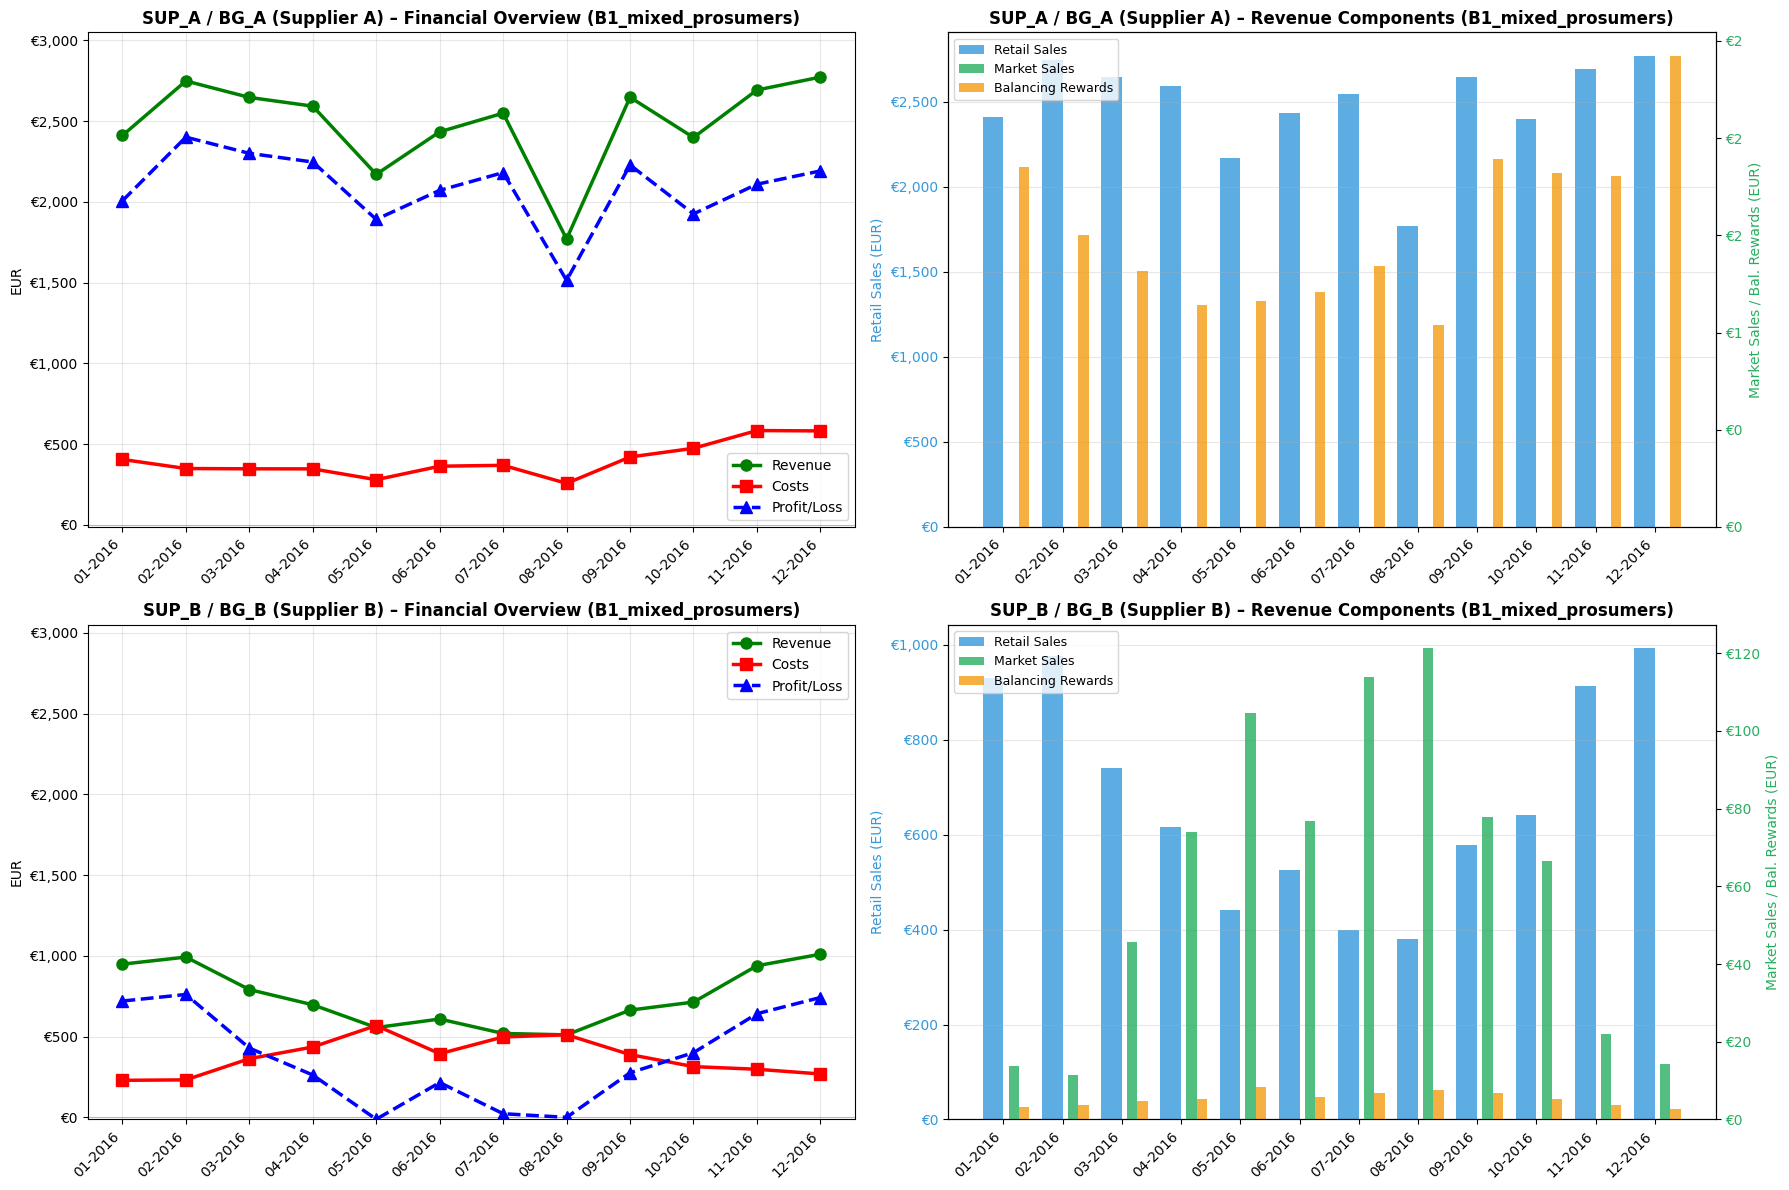

In [35]:
pipe.plot_financials()

## 6. Imbalance Analysis
Visualize system imbalances over time showing the difference between scheduled positions and actual metered values.

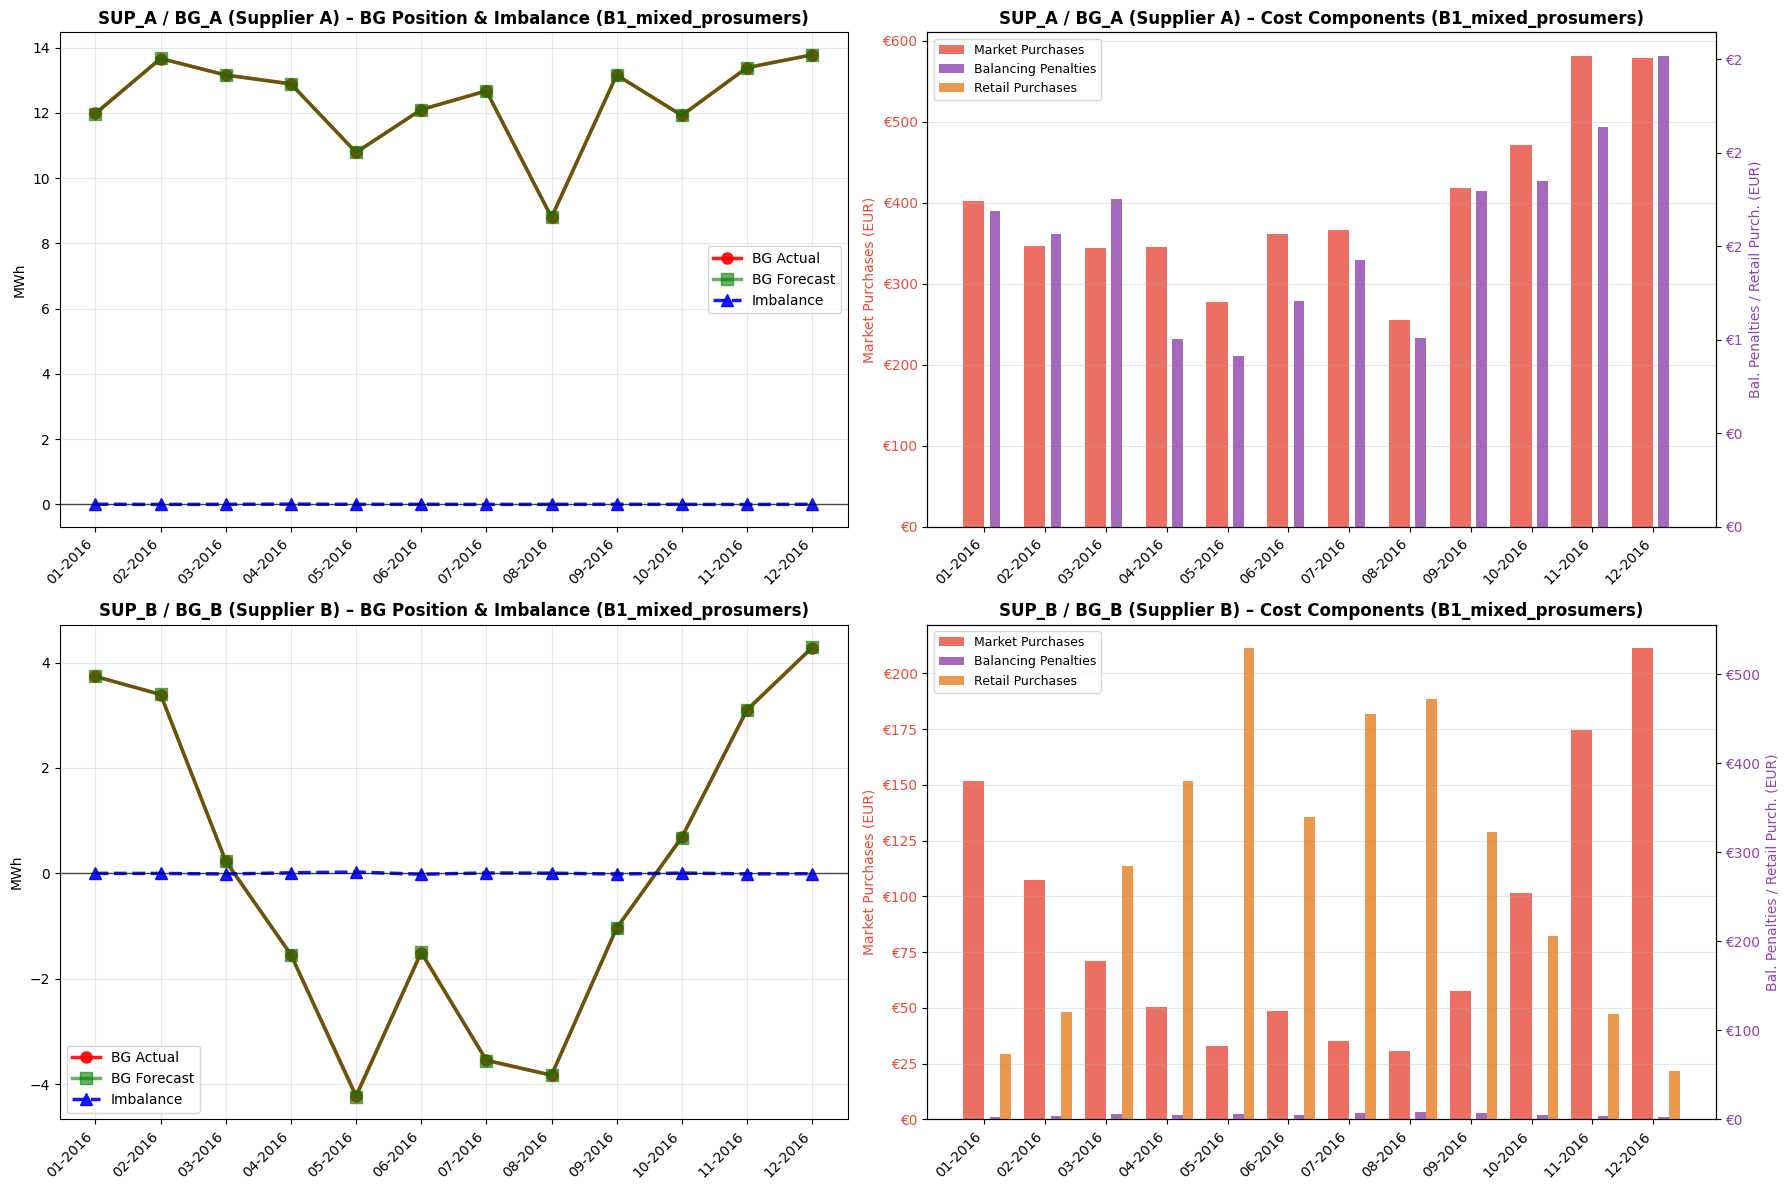

In [36]:
pipe.plot_imbalances()

## 7. Supplier Comparison
Compare financial performance across the two suppliers (SUP_A, SUP_B).

In [37]:
pipe.es_monthly_analysis_df.groupby('supplier_id').agg({
    'profit_loss_eur': 'sum',
    'imbalance_mwh': 'sum'
})

,profit_loss_eur,imbalance_mwh
supplier_id,,
SUP_A,25064.592206,0.003539
SUP_B,4451.264332,-0.004050


In [38]:
from energy_market_operations import EnergyMarketOperations

In [39]:
CONFIG_FILE = "B1_multiple_supplier_no_rec_mixed.json"
pipe = EnergyMarketOperations(CONFIG_FILE, scenario_name="B1_mixed")

In [40]:
pipe.run_all()


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Running full pipeline for: B1_mixed
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━



FileNotFoundError: [Errno 2] No such file or directory: '/home/benjamin/data/scenarios_simulation/B1_multiple_supplier_no_rec_mixed.json'

In [ ]:
pipe.summary()

In [ ]:
pipe.plot_financials()

In [ ]:
pipe.plot_imbalances()

In [ ]:
pipe.es_monthly_analysis_df

In [45]:
import pandas as pd, numpy as np
df = pipe.es_monthly_analysis_df.copy()
df['datetime_dt'] = pd.to_datetime(df['datetime'])
sid = 'SUP_A'
sd = df[df['supplier_id'] == sid].sort_values('datetime_dt')
bg_id = sd['balancing_group_id'].iloc[0]
print(f"SUPPLIER: {sid} / {bg_id}")
bg_actual = sd['balancing_group_actual_mwh'].sum()
bg_forecast = sd['balancing_group_forecast_mwh'].sum()
imbalance = sd['imbalance_mwh'].sum()
bal_reward = sd['revenue_balancing_rewards_eur'].sum()
bal_penalty = sd['cost_balancing_penalties_eur'].sum()
print(f"BG Actual: {bg_actual:.4f}, Forecast: {bg_forecast:.4f}, Imb: {imbalance:+.4f} ({'SHORT' if imbalance>0 else 'LONG'})")
print(f"Bal Reward: €{bal_reward:.2f}, Penalty: €{bal_penalty:.2f}, Net: €{bal_reward-bal_penalty:+.2f}")
rev_rs = sd['revenue_retail_sales_eur'].sum()
rev_ms = sd['revenue_energy_market_sales_eur'].sum()
rev_br = bal_reward
total_rev = sd['total_revenue_eur'].sum()
print(f"Revenue: RS=€{rev_rs:.2f}({rev_rs/total_rev*100:.2f}%), MS=€{rev_ms:.2f}({rev_ms/total_rev*100:.2f}%), BR=€{rev_br:.2f}({rev_br/total_rev*100:.2f}%), Total=€{total_rev:.2f}")
cost_mp = sd['cost_energy_market_purchases_eur'].sum()
cost_bp = bal_penalty
cost_rp = sd['cost_retail_purchases_eur'].sum()
total_cost = sd['total_costs_eur'].sum()
print(f"Costs: MP=€{cost_mp:.2f}({cost_mp/total_cost*100:.2f}%), BP=€{cost_bp:.2f}({cost_bp/total_cost*100:.2f}%), RP=€{cost_rp:.2f}({cost_rp/total_cost*100:.2f}%), Total=€{total_cost:.2f}")
profit = sd['profit_loss_eur'].sum()
print(f"Profit: €{profit:.2f}, avg=€{sd['profit_loss_eur'].mean():.2f}, min=€{sd['profit_loss_eur'].min():.2f}, max=€{sd['profit_loss_eur'].max():.2f}")
print(f"Load: {sd['actual_load_mwh'].sum():.4f}, Gen: {sd['actual_gen_mwh'].sum():.4f}")

SUPPLIER: SUP_A / BG_A
BG Actual: 148.3299, Forecast: 148.3263, Imb: +0.0035 (SHORT)
Bal Reward: €18.51, Penalty: €18.87, Net: €-0.36
Revenue: RS=€29814.30(99.94%), MS=€0.00(0.00%), BR=€18.51(0.06%), Total=€29832.81
Costs: MP=€4749.35(99.60%), BP=€18.87(0.40%), RP=€0.00(0.00%), Total=€4768.22
Profit: €25064.59, avg=€2088.72, min=€1513.39, max=€2400.50
Load: 148.3299, Gen: 0.0000


In [46]:
sid = 'SUP_B'
sd = df[df['supplier_id'] == sid].sort_values('datetime_dt')
bg_id = sd['balancing_group_id'].iloc[0]
print(f"SUPPLIER: {sid} / {bg_id}")
bg_actual = sd['balancing_group_actual_mwh'].sum()
bg_forecast = sd['balancing_group_forecast_mwh'].sum()
imbalance = sd['imbalance_mwh'].sum()
bal_reward = sd['revenue_balancing_rewards_eur'].sum()
bal_penalty = sd['cost_balancing_penalties_eur'].sum()
print(f"BG Actual: {bg_actual:.4f}, Forecast: {bg_forecast:.4f}, Imb: {imbalance:+.4f} ({'SHORT' if imbalance>0 else 'LONG'})")
print(f"Bal Reward: €{bal_reward:.2f}, Penalty: €{bal_penalty:.2f}, Net: €{bal_reward-bal_penalty:+.2f}")
rev_rs = sd['revenue_retail_sales_eur'].sum()
rev_ms = sd['revenue_energy_market_sales_eur'].sum()
rev_br = bal_reward
total_rev = sd['total_revenue_eur'].sum()
print(f"Revenue: RS=€{rev_rs:.2f}({rev_rs/total_rev*100:.2f}%), MS=€{rev_ms:.2f}({rev_ms/total_rev*100:.2f}%), BR=€{rev_br:.2f}({rev_br/total_rev*100:.2f}%), Total=€{total_rev:.2f}")
cost_mp = sd['cost_energy_market_purchases_eur'].sum()
cost_bp = bal_penalty
cost_rp = sd['cost_retail_purchases_eur'].sum()
total_cost = sd['total_costs_eur'].sum()
print(f"Costs: MP=€{cost_mp:.2f}({cost_mp/total_cost*100:.2f}%), BP=€{cost_bp:.2f}({cost_bp/total_cost*100:.2f}%), RP=€{cost_rp:.2f}({cost_rp/total_cost*100:.2f}%), Total=€{total_cost:.2f}")
profit = sd['profit_loss_eur'].sum()
print(f"Profit: €{profit:.2f}, avg=€{sd['profit_loss_eur'].mean():.2f}, min=€{sd['profit_loss_eur'].min():.2f}, max=€{sd['profit_loss_eur'].max():.2f}")
print(f"Load: {sd['actual_load_mwh'].sum():.2f}, Gen: {sd['actual_gen_mwh'].sum():.2f}")

SUPPLIER: SUP_B / BG_B
BG Actual: -0.2551, Forecast: -0.2510, Imb: -0.0040 (LONG)
Bal Reward: €64.23, Penalty: €63.52, Net: €+0.71
Revenue: RS=€8139.09(90.99%), MS=€741.57(8.29%), BR=€64.23(0.72%), Total=€8944.90
Costs: MP=€1072.47(23.87%), BP=€63.52(1.41%), RP=€3357.64(74.72%), Total=€4493.64
Profit: €4451.26, avg=€370.94, min=€-12.50, max=€760.42
Load: 56.42, Gen: 56.68


In [47]:
# Monthly BG positions for both suppliers
for sid in ['SUP_A', 'SUP_B']:
    sd = df[df['supplier_id'] == sid].sort_values('datetime_dt')
    print(f"\n{sid} Monthly BG:")
    for _, r in sd.iterrows():
        print(f"  {r['datetime']}: act={r['balancing_group_actual_mwh']:.4f} fcast={r['balancing_group_forecast_mwh']:.4f} imb={r['imbalance_mwh']:+.4f}")


SUP_A Monthly BG:
  01-2016: act=11.9856 fcast=11.9817 imb=+0.0039
  02-2016: act=13.6674 fcast=13.6704 imb=-0.0030
  03-2016: act=13.1612 fcast=13.1610 imb=+0.0002
  04-2016: act=12.8928 fcast=12.8857 imb=+0.0071
  05-2016: act=10.7909 fcast=10.7909 imb=+0.0000
  06-2016: act=12.1018 fcast=12.1006 imb=+0.0012
  07-2016: act=12.6758 fcast=12.6778 imb=-0.0020
  08-2016: act=8.7990 fcast=8.7992 imb=-0.0002
  09-2016: act=13.1629 fcast=13.1616 imb=+0.0013
  10-2016: act=11.9241 fcast=11.9255 imb=-0.0014
  11-2016: act=13.3867 fcast=13.3908 imb=-0.0042
  12-2016: act=13.7818 fcast=13.7811 imb=+0.0006

SUP_B Monthly BG:
  01-2016: act=3.7373 fcast=3.7372 imb=+0.0001
  02-2016: act=3.3940 fcast=3.3954 imb=-0.0013
  03-2016: act=0.2272 fcast=0.2387 imb=-0.0115
  04-2016: act=-1.5398 fcast=-1.5507 imb=+0.0109
  05-2016: act=-4.2180 fcast=-4.2435 imb=+0.0255
  06-2016: act=-1.5053 fcast=-1.4890 imb=-0.0164
  07-2016: act=-3.5450 fcast=-3.5527 imb=+0.0077
  08-2016: act=-3.8291 fcast=-3.8329 im

In [48]:
# SUP_A Monthly Costs & Revenue
sd = df[df['supplier_id'] == 'SUP_A'].sort_values('datetime_dt')
print("SUP_A Monthly Costs:")
for _, r in sd.iterrows():
    print(f"  {r['datetime']}: MP=€{r['cost_energy_market_purchases_eur']:.2f} BP=€{r['cost_balancing_penalties_eur']:.2f} FI=€{r['cost_retail_purchases_eur']:.2f} Total=€{r['total_costs_eur']:.2f}")
print("\nSUP_A Monthly P/L:")
for _, r in sd.iterrows():
    print(f"  {r['datetime']}: P/L=€{r['profit_loss_eur']:.2f}")

SUP_A Monthly Costs:
  01-2016: MP=€402.72 BP=€1.69 FI=€0.00 Total=€404.41
  02-2016: MP=€346.58 BP=€1.57 FI=€0.00 Total=€348.15
  03-2016: MP=€344.63 BP=€1.75 FI=€0.00 Total=€346.39
  04-2016: MP=€344.97 BP=€1.00 FI=€0.00 Total=€345.97
  05-2016: MP=€278.02 BP=€0.92 FI=€0.00 Total=€278.94
  06-2016: MP=€361.23 BP=€1.21 FI=€0.00 Total=€362.44
  07-2016: MP=€366.70 BP=€1.43 FI=€0.00 Total=€368.12
  08-2016: MP=€255.23 BP=€1.01 FI=€0.00 Total=€256.24
  09-2016: MP=€417.75 BP=€1.79 FI=€0.00 Total=€419.54
  10-2016: MP=€471.61 BP=€1.85 FI=€0.00 Total=€473.46
  11-2016: MP=€581.22 BP=€2.14 FI=€0.00 Total=€583.36
  12-2016: MP=€578.69 BP=€2.52 FI=€0.00 Total=€581.20

SUP_A Monthly P/L:
  01-2016: P/L=€2006.54
  02-2016: P/L=€2400.50
  03-2016: P/L=€2300.33
  04-2016: P/L=€2246.63
  05-2016: P/L=€1891.20
  06-2016: P/L=€2071.22
  07-2016: P/L=€2181.05
  08-2016: P/L=€1513.39
  09-2016: P/L=€2228.10
  10-2016: P/L=€1925.11
  11-2016: P/L=€2109.17
  12-2016: P/L=€2191.36


In [49]:
# SUP_B Monthly Costs & Revenue
sd = df[df['supplier_id'] == 'SUP_B'].sort_values('datetime_dt')
print("SUP_B Monthly Costs:")
for _, r in sd.iterrows():
    print(f"  {r['datetime']}: MP=€{r['cost_energy_market_purchases_eur']:.2f} BP=€{r['cost_balancing_penalties_eur']:.2f} FI=€{r['cost_retail_purchases_eur']:.2f} Total=€{r['total_costs_eur']:.2f}")
print("\nSUP_B Monthly P/L:")
for _, r in sd.iterrows():
    print(f"  {r['datetime']}: P/L=€{r['profit_loss_eur']:.2f}")

SUP_B Monthly Costs:
  01-2016: MP=€151.76 BP=€3.01 FI=€73.82 Total=€228.59
  02-2016: MP=€107.15 BP=€3.64 FI=€120.73 Total=€231.51
  03-2016: MP=€71.23 BP=€6.46 FI=€284.74 Total=€362.43
  04-2016: MP=€50.40 BP=€4.67 FI=€379.97 Total=€435.04
  05-2016: MP=€32.92 BP=€6.08 FI=€528.88 Total=€567.89
  06-2016: MP=€48.43 BP=€5.39 FI=€339.56 Total=€393.38
  07-2016: MP=€35.09 BP=€6.71 FI=€455.37 Total=€497.17
  08-2016: MP=€30.63 BP=€8.42 FI=€471.85 Total=€510.90
  09-2016: MP=€57.52 BP=€7.28 FI=€323.21 Total=€388.01
  10-2016: MP=€101.69 BP=€5.27 FI=€206.53 Total=€313.48
  11-2016: MP=€174.45 BP=€3.82 FI=€118.93 Total=€297.20
  12-2016: MP=€211.20 BP=€2.77 FI=€54.06 Total=€268.04

SUP_B Monthly P/L:
  01-2016: P/L=€719.60
  02-2016: P/L=€760.42
  03-2016: P/L=€428.31
  04-2016: P/L=€261.44
  05-2016: P/L=€-12.50
  06-2016: P/L=€214.87
  07-2016: P/L=€21.81
  08-2016: P/L=€-0.72
  09-2016: P/L=€275.50
  10-2016: P/L=€399.78
  11-2016: P/L=€641.21
  12-2016: P/L=€741.53


In [50]:
# Config participant structure
cfg = pipe.config
# Check keys
if cfg.get('consumers'):
    print("Consumer keys:", list(cfg['consumers'][0].keys()))
if cfg.get('prosumers'):
    print("Prosumer keys:", list(cfg['prosumers'][0].keys()))

for s in cfg['suppliers']:
    sid = s['supplier_id']
    sname = s['supplier_name']
    bgs = [bg['balancing_group_id'] for bg in s['balancing_groups']]
    consumers = [c.get('participant_id', c.get('id', c.get('name', '?'))) for c in cfg.get('consumers', []) if c['supplier']['supplier_id'] == sid]
    prosumers = [p.get('participant_id', p.get('id', p.get('name', '?'))) for p in cfg.get('prosumers', []) if p['supplier']['supplier_id'] == sid]
    print(f"{sid} ({sname}): BGs={bgs}, #Consumers={len(consumers)}, #Prosumers={len(prosumers)}")

print(f"\nCombined Revenue: €{df['total_revenue_eur'].sum():.2f}")
print(f"Combined Costs:   €{df['total_costs_eur'].sum():.2f}")
print(f"Combined Profit:  €{df['profit_loss_eur'].sum():.2f}")
print(f"Total Load: {df['actual_load_mwh'].sum():.2f} MWh")
print(f"Total Gen:  {df['actual_gen_mwh'].sum():.2f} MWh")

Consumer keys: ['meter_id', 'name', 'node_id', 'supplier', 'load']
Prosumer keys: ['meter_id', 'name', 'node_id', 'supplier', 'load', 'res']
SUP_A (Supplier A): BGs=['BG_A'], #Consumers=6, #Prosumers=0
SUP_B (Supplier B): BGs=['BG_B'], #Consumers=0, #Prosumers=3

Combined Revenue: €38777.71
Combined Costs:   €9261.86
Combined Profit:  €29515.86
Total Load: 204.75 MWh
Total Gen:  56.68 MWh
